In [30]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns


## About the Dataset

The California Housing dataset contains information about housing blocks in California. Each row represents a housing block, with features describing its housing characteristics, population, and geographical location.

**Goal/Target:** Predict the median house value of a housing block using the given features.

**Input Features:** 

**Features Description**
1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the house w.r.t ocean/sea


## Load Dataset


In [31]:
df = pd.read_csv("../Data/Raw/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [32]:
df.shape #Shape of Data: Rows -> 20640 Columns -> 10


(20640, 10)

In [33]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [34]:
df.describe() #Doing Baasic Statistical Analysis of Whole Data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [35]:
# Performing Analysis of our target variable
df['median_house_value'].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [36]:
df.isnull().sum() #There are total 207 missing values in total_bedrooms column

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [37]:
#Seprating Numerical Features and Categorical Features in Data

numerical_features = df.select_dtypes(include=["int64", 'float64']).columns.tolist()
print(numerical_features)

categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
print(categorical_features)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
['ocean_proximity']


C:\Users\HP\AppData\Local\Temp\ipykernel_12236\2165168291.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


In [38]:
# Checking for duplicate values in data
df.duplicated().sum()
 
# No duplicate value in data

np.int64(0)

In [39]:
df.nunique() # Show how many unique values exist

longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
median_house_value     3842
ocean_proximity           5
dtype: int64

### Categorical Feature Analysis

In [58]:
df["ocean_proximity"].value_counts(normalize=True)*100 
#There are 5 types of Categories in ocean_proximity
# Island is the rare category

ocean_proximity
<1H OCEAN     44.263566
INLAND        31.739341
NEAR OCEAN    12.877907
NEAR BAY      11.094961
ISLAND         0.024225
Name: proportion, dtype: float64

In [41]:
df["ocean_proximity"].describe()

count         20640
unique            5
top       <1H OCEAN
freq           9136
Name: ocean_proximity, dtype: object

### Numerical Feature Analysis


In [42]:
#removed the Target Variable
numerical_features.remove("median_house_value")


In [50]:
df[numerical_features].describe().T


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001


In [51]:
df[numerical_features].skew().sort_values(ascending=False)

population            4.935858
total_rooms           4.147343
total_bedrooms        3.459546
households            3.410438
median_income         1.646657
latitude              0.465953
housing_median_age    0.060331
longitude            -0.297801
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

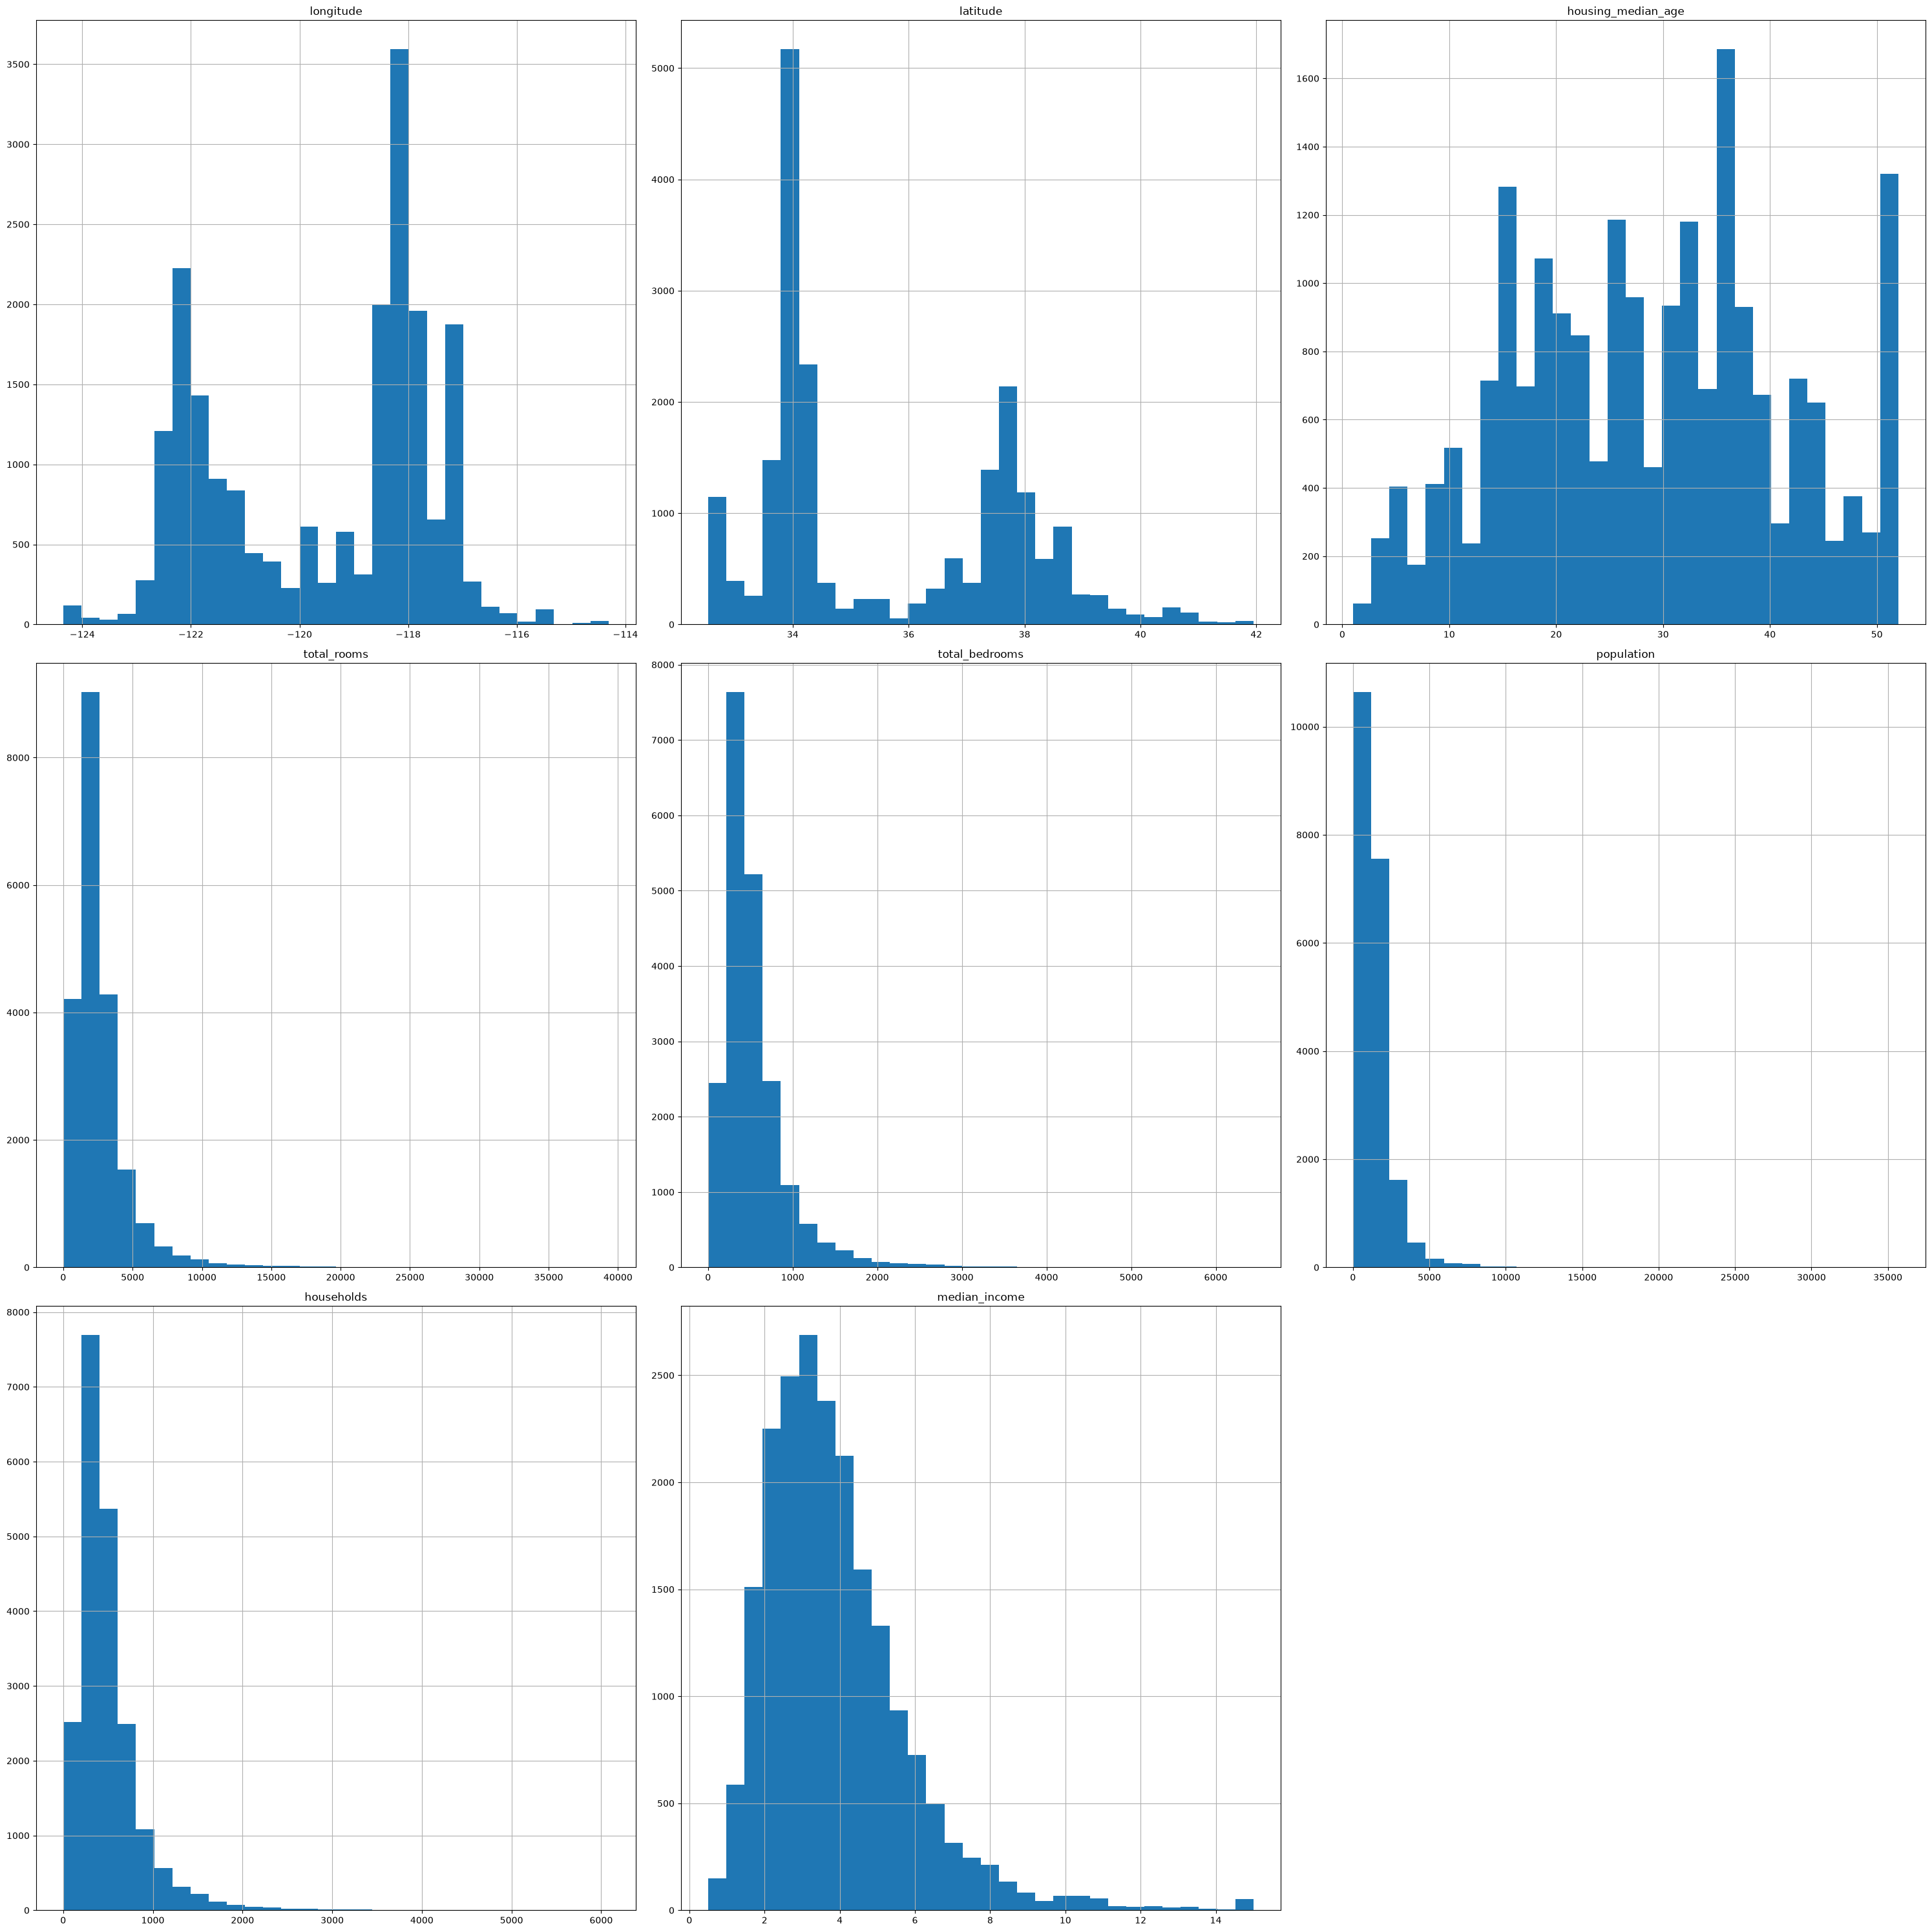

In [57]:
import matplotlib.pyplot as plt

df[numerical_features].hist(
    figsize=(30,30),
    bins = 30
)
plt.tight_layout()
plt.show


# population, total_rooms, total_bedrooms, households, median_income are highly right skewed
#longitude and latitude have a bimodal distribution
#housing_median_age is kind of normally distributed

In [56]:
df[numerical_features].describe().loc[['min', 'max']].T

,min,max
longitude,-124.3500,-114.3100
latitude,32.5400,41.9500
housing_median_age,1.0000,52.0000
total_rooms,2.0000,39320.0000
total_bedrooms,1.0000,6445.0000
population,3.0000,35682.0000
households,1.0000,6082.0000
median_income,0.4999,15.0001


### Outlier And Anomly Detection

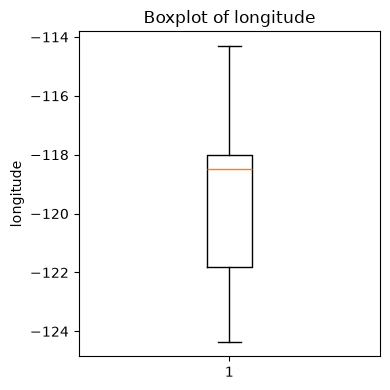

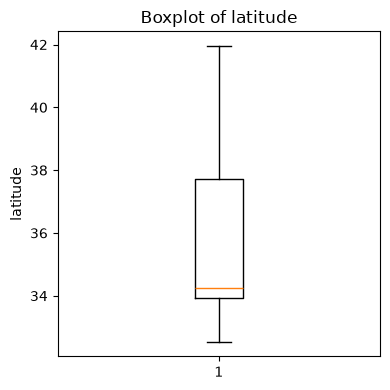

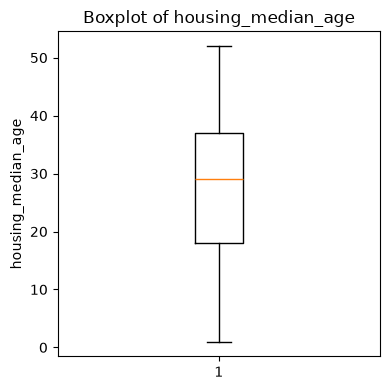

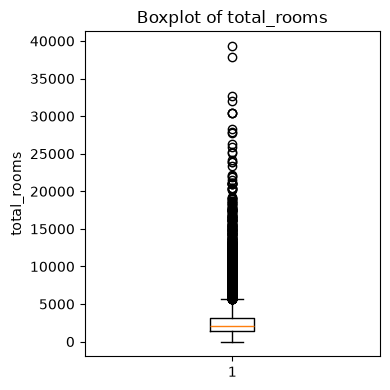

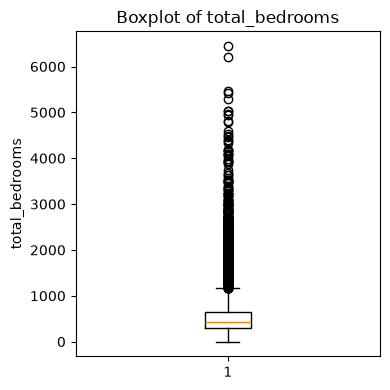

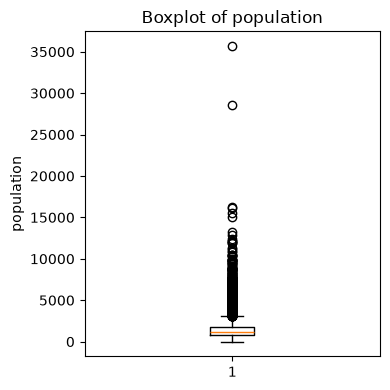

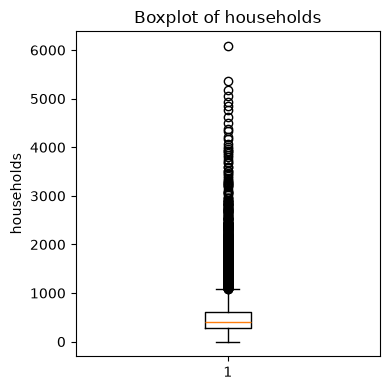

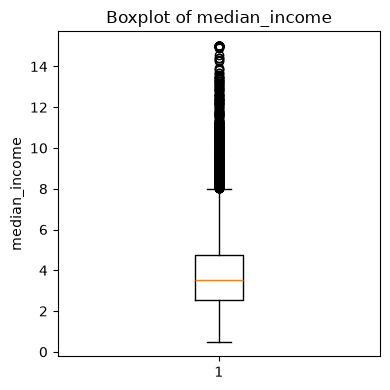

In [62]:
for i in numerical_features:
    plt.figure(figsize=(4,4))
    plt.boxplot(df[i].dropna())
    plt.title(f"Boxplot of {i}")
    plt.ylabel(i)
    plt.tight_layout()
    plt.show


In [63]:
outlier_summary = {}

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary[col] = outliers

outlier_summary

{'longitude': np.int64(0),
 'latitude': np.int64(0),
 'housing_median_age': np.int64(0),
 'total_rooms': np.int64(1287),
 'total_bedrooms': np.int64(1271),
 'population': np.int64(1196),
 'households': np.int64(1220),
 'median_income': np.int64(681)}

In [ ]:
sns.heatmap(df[numerical_features].corr().values)
plt.show()

TypeError: 'numpy.ndarray' object is not callable